# Conditional Expectation as Projection: $L^2$, $L^p$, and “Residuals”

*A visual reading: geometry → martingales → computation.*

## Roadmap

1. **Operator construction (Hilbert / Riesz):** why $\mathbb E[\cdot\mid\Sigma_0]$ exists/unique on $L^2$
2. **Projection geometry:** best $L^2$ predictor + orthogonal residual
3. **Operator properties pack:** tower/idempotence, Jensen, “take out what is known”, $L^1$ contraction
4. **Conditional variance:** law of total variance (variance decomposition)
5. **Dyadic filtrations & Doob martingales:** $k\mapsto \mathbb E[f\mid\mathcal F_k]$ as zooming/projection
6. **Conditioning on a point:** Gaussian case as “regular conditional expectation in action”
7. **Computation lens:** regression/binning/kernel smoothing as *estimators* of conditional expectation

---

**Guiding metaphor:**

> $$Y = \underbrace{\mathbb E[Y\mid \mathcal G]}_{\text{predictable part}} + \underbrace{\big(Y-\mathbb E[Y\mid \mathcal G]\big)}_{\text{residual / innovation}}$$
> 
> 
> The “residual” behaves like **mean-zero noise given the information $\mathcal G$** — this is the precise sense in which it’s an *innovation*.


In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from math import erf

rng = np.random.default_rng(0)

# No hard-coded colors
plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

_fig_counter = 0
def show_caption(text, label=None):
    global _fig_counter
    _fig_counter += 1
    prefix = f"**Figure {_fig_counter}.** "
    if label is not None:
        prefix += f"({label}) "
    display(Markdown(prefix + text))

def norm_cdf(x):
    # Standard normal CDF via erf, vectorized
    x = np.asarray(x)
    return 0.5 * (1.0 + np.vectorize(erf)(x / np.sqrt(2.0)))


## 1) Existence/uniqueness on $L^2$: the Riesz/Hilbert construction

One standard construction builds conditional expectation as a **linear continuous map**

$$T: L^2(\Omega,\Sigma,P)\to L^2(\Omega,\Sigma_0,P),\qquad T(X)=\mathbb E[X\mid \Sigma_0],$$

characterized by

$$\int_A X\,dP=\int_A T(X)\,dP\quad \forall A\in\Sigma_0.$$

Why is this “inevitable”? Because $L^2$ is a Hilbert space; bounded linear functionals correspond to inner products (Riesz representation).
So $\mathbb E[\cdot\mid\Sigma_0]$ is literally the **adjoint** of the inclusion map $L^2(\Sigma_0)\hookrightarrow L^2(\Sigma)$.

**Upgrade mindset:** this isn’t just a definition — it’s a *projection machine*.


## 2) Projection geometry: best $L^2$ predictor and orthogonal residual

Let $\mathcal G\subseteq \Sigma$ be a sub-$\sigma$-algebra. Then $L^2(\mathcal G)$ is a closed subspace of $L^2(\Sigma)$.
The conditional expectation $\mathbb E[Y\mid\mathcal G]$ is the **orthogonal projection** of $Y$ onto $L^2(\mathcal G)$.

Two equivalent “power tools”:

1. **Best predictor:**

$$\mathbb E[(Y-Z)^2]\ \text{is minimized over }Z\in L^2(\mathcal G)\ \text{by }Z=\mathbb E[Y\mid\mathcal G].$$

2. **Residual orthogonality:**

$$\mathbb E\big[(Y-\mathbb E[Y\mid\mathcal G])\,Z\big]=0\quad \forall Z\in L^2(\mathcal G).$$

This is the mathematical version of “residual = innovation”.


Approx E[R*1], E[R*X], E[R*X^2] = [-4.92939023e-17 -1.11022302e-19 -2.22044605e-19]


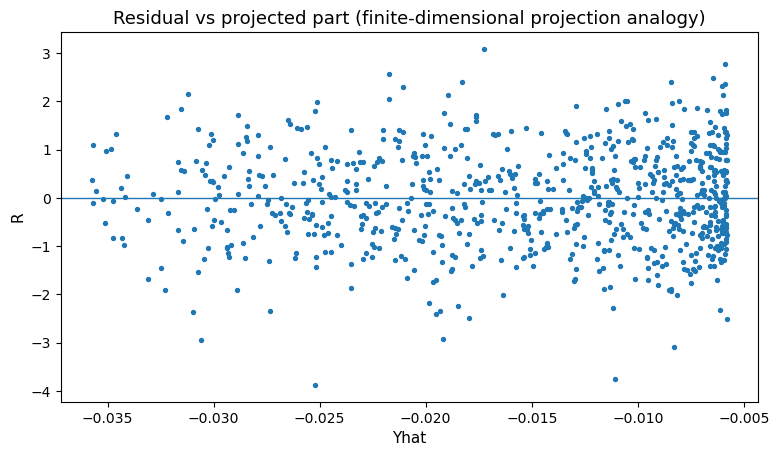

**Figure 1.** Residual shows no systematic dependence on the projected subspace features (empirical orthogonality).

In [2]:
# Finite-dimensional analogy: orthogonal projection in R^n
n = 4000
Y = rng.normal(size=n)

# Think of "information" as a feature space span{1, X, X^2}
X = rng.uniform(-2, 2, size=n)
Phi = np.column_stack([np.ones(n), X, X**2])  # feature matrix

# Projection of Y onto span(Phi): yhat = Phi (Phi^T Phi)^{-1} Phi^T Y
A = Phi.T @ Phi
b = Phi.T @ Y
coef = np.linalg.solve(A, b)
Yhat = Phi @ coef
R = Y - Yhat

# Diagnostics: residual orthogonality to columns of Phi
inner = (Phi * R[:, None]).mean(axis=0)  # approx E[R * feature]
print("Approx E[R*1], E[R*X], E[R*X^2] =", inner)

plt.figure()
plt.scatter(Yhat[:800], R[:800], s=8)
plt.title("Residual vs projected part (finite-dimensional projection analogy)")
plt.xlabel("Yhat")
plt.ylabel("R")
plt.axhline(0.0, linewidth=1.0)
plt.show()
show_caption("Residual shows no systematic dependence on the projected subspace features (empirical orthogonality).")


## 3) Visual A: $\mathbb E[Y\mid X]$ as a curve (nonlinear regression viewpoint)

We simulate

$$Y=g(X)+\varepsilon,\quad \varepsilon\perp X,\ \mathbb E[\varepsilon]=0,$$

so $\mathbb E[Y\mid X=x]=g(x)$.

We’ll estimate $\mathbb E[Y\mid X]$ by:

* **binning** (conditioning on a coarse $\sigma(\text{bin}(X))$),
* **kernel smoothing** (a continuous estimator, still “conditional mean-ish”).

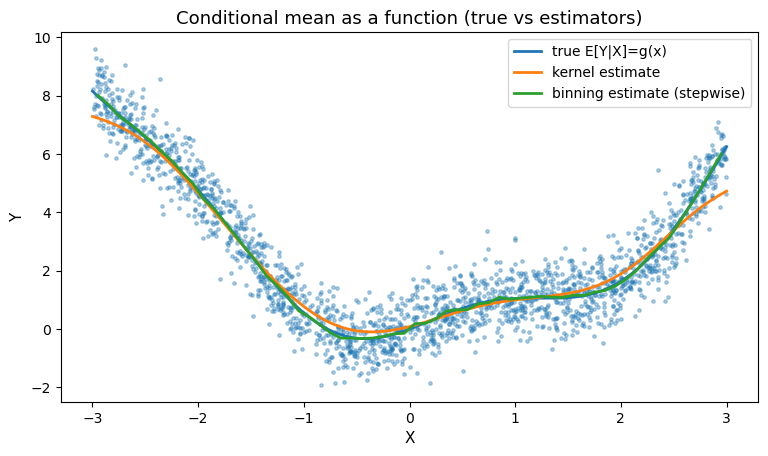

**Figure 2.** Binning is literally conditional expectation on a coarse sigma-algebra; kernel regression is a smooth estimator of the same target.

In [3]:
n = 8000
X = rng.uniform(-3, 3, size=n)
eps = rng.normal(0, 0.7, size=n)
g = lambda x: 0.8*x**2 - 0.4*x + 0.8*np.sin(2.2*x)
Y = g(X) + eps

# Binning estimator: E[Y | bin(X)]
B = 60
bins = np.linspace(X.min(), X.max(), B+1)
idx = np.digitize(X, bins) - 1
idx = np.clip(idx, 0, B-1)

bin_means = np.zeros(B)
bin_counts = np.zeros(B)
for j in range(B):
    m = (idx == j)
    bin_counts[j] = m.sum()
    bin_means[j] = Y[m].mean() if bin_counts[j] > 0 else np.nan

x_centers = 0.5*(bins[:-1] + bins[1:])
yhat_bin = bin_means[idx]

# Kernel regression (Nadaraya–Watson)
def kernel_regress(x_query, X, Y, h):
    # returns E[Y|X=x] estimate at x_query points
    x_query = np.asarray(x_query)
    out = np.zeros_like(x_query, dtype=float)
    for i, x0 in enumerate(x_query):
        w = np.exp(-0.5*((X - x0)/h)**2)
        out[i] = np.sum(w*Y) / np.sum(w)
    return out

x_grid = np.linspace(-3, 3, 300)
y_true = g(x_grid)
y_ker = kernel_regress(x_grid, X, Y, h=0.35)

plt.figure()
plt.scatter(X[:2000], Y[:2000], s=6, alpha=0.35)
plt.plot(x_grid, y_true, linewidth=2.0, label="true E[Y|X]=g(x)")
plt.plot(x_grid, y_ker, linewidth=2.0, label="kernel estimate")
plt.plot(x_centers, bin_means, linewidth=2.0, label="binning estimate (stepwise)")
plt.title("Conditional mean as a function (true vs estimators)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()
show_caption("Binning is literally conditional expectation on a coarse sigma-algebra; kernel regression is a smooth estimator of the same target.")


## 4) Visual B: residual orthogonality (empirical check)

Let $\mathcal G=\sigma(\text{bin}(X))$. Then the “residual”

$$R = Y - \mathbb E[Y\mid \mathcal G]$$

should satisfy $\mathbb E[R\cdot Z]=0$ for all $Z\in L^2(\mathcal G)$.

In practice, we test against simple functions of $X$.


E[R*1] ≈ 0.0000e+00
E[R*X] ≈ 1.7778e-04
E[R*X^2] ≈ 7.1827e-03
E[R*sin(2X)] ≈ 1.3256e-03
E[R*bin mean itself] ≈ 6.7502e-17


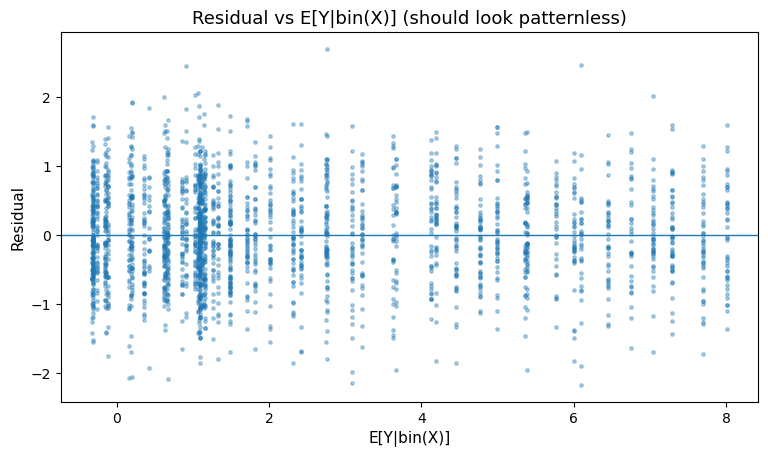

**Figure 3.** Orthogonality doesn’t mean independence, but it kills all linear correlations with G-measurable functions.

In [4]:
R = Y - yhat_bin
tests = {
    "1": np.ones_like(X),
    "X": X,
    "X^2": X**2,
    "sin(2X)": np.sin(2*X),
    "bin mean itself": yhat_bin
}
for name, Z in tests.items():
    val = np.mean(R*Z)
    print(f"E[R*{name}] ≈ {val:.4e}")

plt.figure()
plt.scatter(yhat_bin[:2500], R[:2500], s=6, alpha=0.35)
plt.title("Residual vs E[Y|bin(X)] (should look patternless)")
plt.xlabel("E[Y|bin(X)]")
plt.ylabel("Residual")
plt.axhline(0.0, linewidth=1.0)
plt.show()
show_caption("Orthogonality doesn’t mean independence, but it kills all linear correlations with G-measurable functions.")


## 5) Operator properties pack

These are not “decorations”; they are the algebra of information.

* **Tower / idempotence:** conditioning twice is the same as once (projection behavior).
* **Jensen:** convexity survives conditioning:

$$\phi(\mathbb E[X\mid\mathcal G])\le \mathbb E[\phi(X)\mid\mathcal G].$$


* **$L^1$ contraction:** $\mathbb E| \mathbb E[X\mid\mathcal G]|\le \mathbb E|X|$.

We’ll verify all three numerically on the same simulated data.


Max |E[E[Y|G]|G] - E[Y|G]| (empirical): 3.552713678800501e-15
Fraction of points violating Jensen (should be ~0 up to MC noise): 0.0
E|E[Y|G]| = 2.428036847710184
E|Y|      = 2.52505503724173


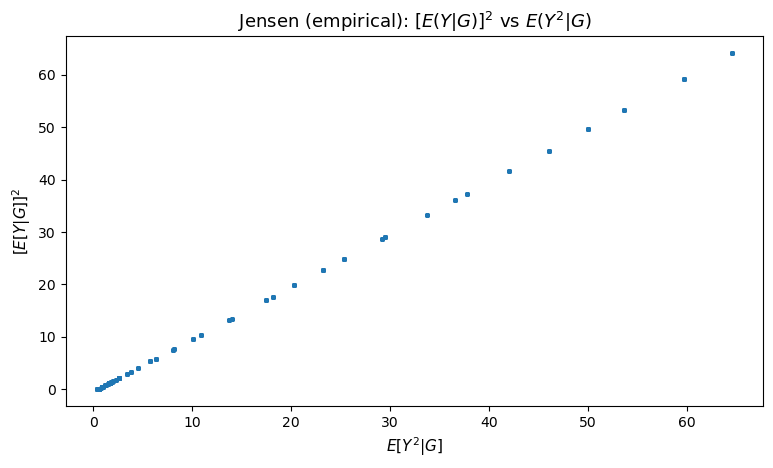

**Figure 4.** Points should lie below the diagonal because $[E(Y|G)]^2 \le E(Y^2|G)$ (Jensen).

In [5]:
# Tower / idempotence numerically for G = sigma(bin(X)):
# E[E[Y|G] | G] == E[Y|G]
yhat_again = np.zeros_like(yhat_bin)
for j in range(B):
    m = (idx == j)
    yhat_again[m] = yhat_bin[m].mean()
print("Max |E[E[Y|G]|G] - E[Y|G]| (empirical):", np.max(np.abs(yhat_again - yhat_bin)))

# Jensen check with convex phi(z)=z^2: phi(E[Y|G]) <= E[phi(Y)|G]
phi = lambda z: z**2
lhs = phi(yhat_bin)

E_phiY_given_G = np.zeros_like(Y)
for j in range(B):
    m = (idx == j)
    E_phiY_given_G[m] = phi(Y[m]).mean()

viol = np.mean(lhs > E_phiY_given_G + 1e-10)
print("Fraction of points violating Jensen (should be ~0 up to MC noise):", viol)

# L1 contraction: E|E[Y|G]| <= E|Y|
print("E|E[Y|G]| =", np.mean(np.abs(yhat_bin)))
print("E|Y|      =", np.mean(np.abs(Y)))

plt.figure()
plt.scatter(E_phiY_given_G[:2000], lhs[:2000], s=6, alpha=0.35)
plt.title(r"Jensen (empirical): $[E(Y|G)]^2$ vs $E(Y^2|G)$")
plt.xlabel(r"$E[Y^2|G]$")
plt.ylabel(r"$[E[Y|G]]^2$")
plt.show()
show_caption("Points should lie below the diagonal because $[E(Y|G)]^2 \\le E(Y^2|G)$ (Jensen).")


## 6) Conditional variance: where uncertainty lives

A key identity (often called the **law of total variance**) is:

$$\mathrm{Var}(Y)=\mathbb E[\mathrm{Var}(Y\mid\mathcal G)] + \mathrm{Var}(\mathbb E[Y\mid\mathcal G]).$$

Interpretation:

* $\mathbb E[\mathrm{Var}(Y\mid\mathcal G)]$: “noise left after knowing $\mathcal G$”
* $\mathrm{Var}(\mathbb E[Y\mid\mathcal G])$: “uncertainty due to $\mathcal G$ itself”

We’ll estimate both terms as we refine information (more bins).


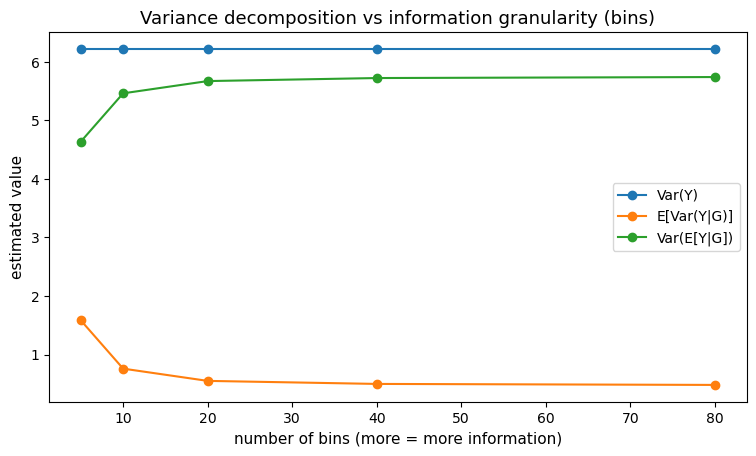

**Figure 5.** As information increases, explained variance Var(E[Y|G]) tends to rise and residual variance E[Var(Y|G)] tends to fall (sum stays ~constant).

In [6]:
def variance_decomp(X, Y, B):
    bins = np.linspace(X.min(), X.max(), B+1)
    idx = np.digitize(X, bins) - 1
    idx = np.clip(idx, 0, B-1)

    EY_G = np.zeros_like(Y)
    VarY_G = np.zeros_like(Y)

    for j in range(B):
        m = (idx == j)
        if m.sum() == 0:
            continue
        mu = Y[m].mean()
        v = Y[m].var()
        EY_G[m] = mu
        VarY_G[m] = v

    total = Y.var()
    term1 = VarY_G.mean()                 # E[Var(Y|G)]
    term2 = EY_G.var()                    # Var(E[Y|G])
    return total, term1, term2

Bs = [5, 10, 20, 40, 80]
totals, t1s, t2s = [], [], []
for Btmp in Bs:
    total, term1, term2 = variance_decomp(X, Y, Btmp)
    totals.append(total); t1s.append(term1); t2s.append(term2)

plt.figure()
plt.plot(Bs, totals, marker="o", label="Var(Y)")
plt.plot(Bs, t1s, marker="o", label="E[Var(Y|G)]")
plt.plot(Bs, t2s, marker="o", label="Var(E[Y|G])")
plt.title("Variance decomposition vs information granularity (bins)")
plt.xlabel("number of bins (more = more information)")
plt.ylabel("estimated value")
plt.legend()
plt.show()
show_caption("As information increases, explained variance Var(E[Y|G]) tends to rise and residual variance E[Var(Y|G)] tends to fall (sum stays ~constant).")


## 7) Dyadic filtrations & Doob martingales: “zooming in” as repeated projection

On $[0,1)$, let $\mathcal{F}_k$ be generated by dyadic intervals of length $2^{-k}$.
Then $\mathbb{E}[f\mid\mathcal{F}_k]$ is piecewise constant — literally the average of $f$ on each dyadic cell.

As $k$ increases, $\mathbb{E}[f\mid\mathcal{F}_k]$ is a martingale in $k$ (a **Doob martingale**) and converges to $f$ in $L^2$ under mild conditions.


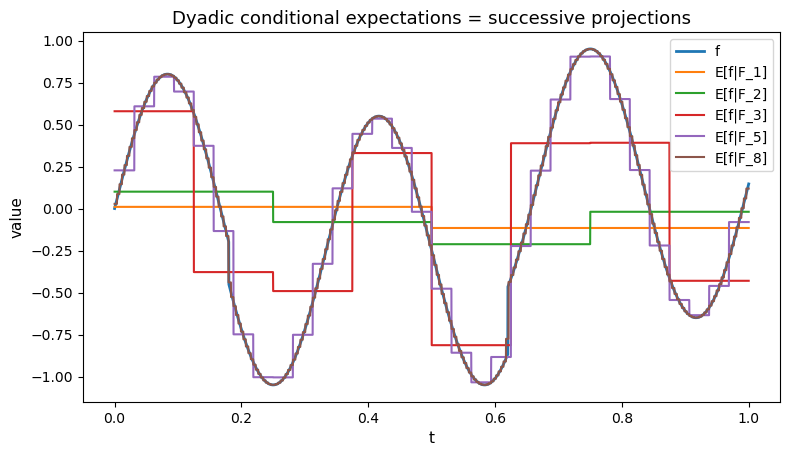

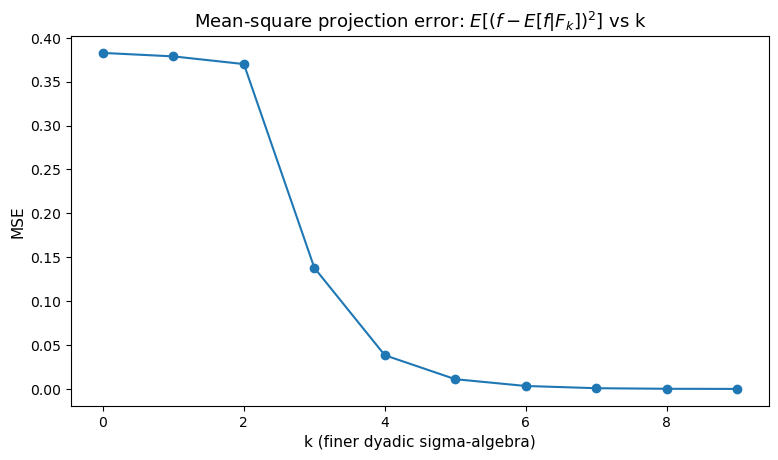

**Figure 6.** Projection error decreases as information increases: a clean geometric signature of conditional expectation as orthogonal projection.

In [7]:
def f(t):
    # smooth + jump features
    return 0.8*np.sin(2*np.pi*3*t) + 0.4*(t>0.62) - 0.25*(t>0.18)

gridN = 4096
t = np.linspace(0, 1, gridN, endpoint=False)
ft = f(t)

def dyadic_condexp(values, k):
    # values on uniform grid; group into blocks of length 2^{-k}
    N = len(values)
    block = N // (2**k)
    out = np.zeros_like(values)
    for j in range(2**k):
        sl = slice(j*block, (j+1)*block)
        out[sl] = values[sl].mean()
    return out

Ks = [1, 2, 3, 5, 8]
plt.figure()
plt.plot(t, ft, linewidth=2.0, label="f")
for k in Ks:
    Ek = dyadic_condexp(ft, k)
    plt.plot(t, Ek, linewidth=1.5, label=f"E[f|F_{k}]")
plt.title("Dyadic conditional expectations = successive projections")
plt.xlabel("t")
plt.ylabel("value")
plt.legend()
plt.show()

# L2 error vs k
errs = []
for k in range(0, 10):
    Ek = dyadic_condexp(ft, k)
    errs.append(np.mean((ft - Ek)**2))
plt.figure()
plt.plot(range(0,10), errs, marker="o")
plt.title(r"Mean-square projection error: $E[(f - E[f|F_k])^2]$ vs k")
plt.xlabel("k (finer dyadic sigma-algebra)")
plt.ylabel("MSE")
plt.show()
show_caption("Projection error decreases as information increases: a clean geometric signature of conditional expectation as orthogonal projection.")


## 8) Conditioning on a point: Gaussian case (regular conditional expectation in action)

For continuous $X$, the phrase “$\mathbb E[Y\mid X=x]$” is shorthand for a **version** of the conditional expectation, defined via a regular conditional distribution (when it exists).

In the bivariate normal case, conditioning becomes beautifully explicit:

$$\mathbb E[Y\mid X]=\mu_Y + \rho \frac{\sigma_Y}{\sigma_X}(X-\mu_X),$$

so the conditional expectation is **linear**.


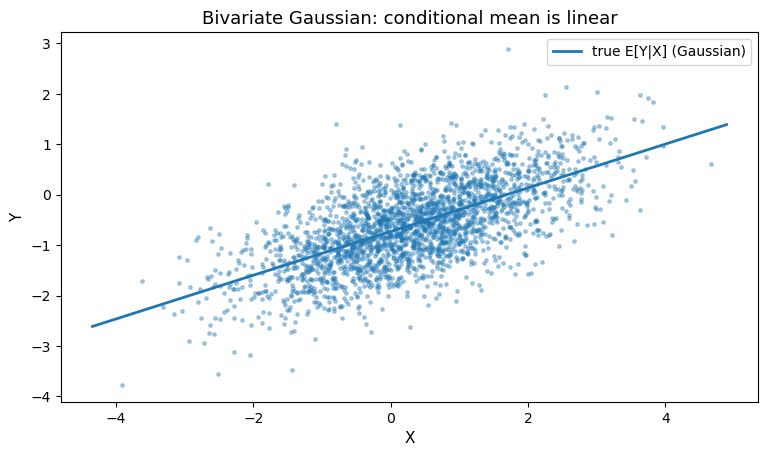

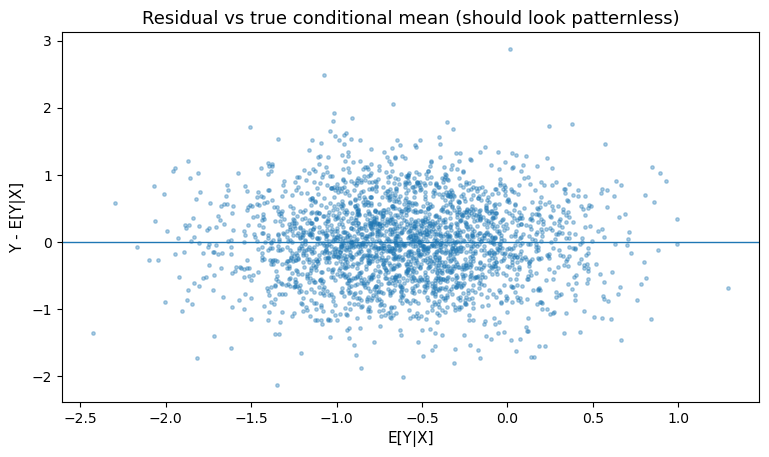

**Figure 7.** In the Gaussian case, conditioning is exact and linear; the residual is independent of X (stronger than orthogonality).

In [8]:
# Simulate bivariate normal (X,Y)
N = 12000
muX, muY = 0.3, -0.6
sigX, sigY = 1.2, 0.8
rho = 0.65

Z1 = rng.normal(size=N)
Z2 = rng.normal(size=N)
Xg = muX + sigX*Z1
Yg = muY + sigY*(rho*Z1 + np.sqrt(1-rho**2)*Z2)

# true conditional mean
EY_given_X = muY + rho*(sigY/sigX)*(Xg - muX)

# binning estimate for comparison
B = 50
bins = np.linspace(Xg.min(), Xg.max(), B+1)
idx = np.clip(np.digitize(Xg, bins)-1, 0, B-1)
bin_mean = np.zeros(B)
for j in range(B):
    m = (idx==j)
    bin_mean[j] = Yg[m].mean() if m.sum() else np.nan
EY_hat = bin_mean[idx]

plt.figure()
plt.scatter(Xg[:2500], Yg[:2500], s=6, alpha=0.35)
xline = np.linspace(Xg.min(), Xg.max(), 200)
yline = muY + rho*(sigY/sigX)*(xline - muX)
plt.plot(xline, yline, linewidth=2.0, label="true E[Y|X] (Gaussian)")
plt.title("Bivariate Gaussian: conditional mean is linear")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

plt.figure()
plt.scatter(EY_given_X[:2500], (Yg - EY_given_X)[:2500], s=6, alpha=0.35)
plt.title("Residual vs true conditional mean (should look patternless)")
plt.xlabel("E[Y|X]")
plt.ylabel("Y - E[Y|X]")
plt.axhline(0.0, linewidth=1.0)
plt.show()
show_caption("In the Gaussian case, conditioning is exact and linear; the residual is independent of X (stronger than orthogonality).")


## 9) Computation lens: conditional expectation as an object you *estimate*

In Monte Carlo practice, $\mathbb E[\cdot\mid\mathcal G]$ is often approximated by:

* binning / stratification (coarse $\sigma$-algebras),
* regression (projection onto a chosen basis),
* kernels / splines (nonparametric smoothing).

This is not optional — it’s the backbone of many dynamic pricing algorithms (e.g. regression Monte Carlo).


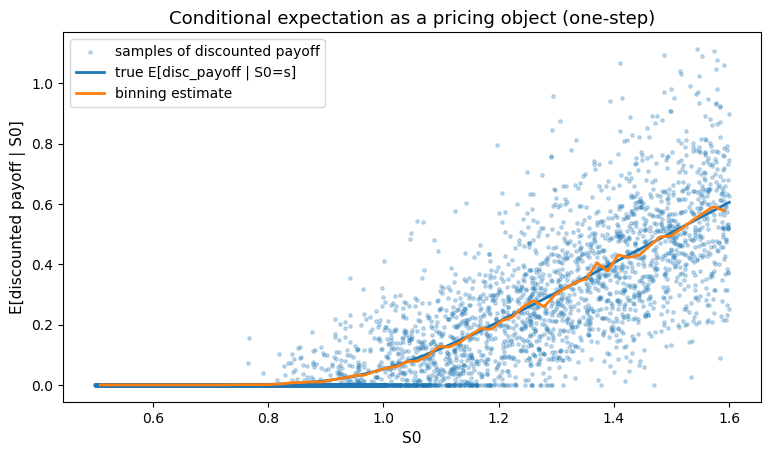

**Figure 8.** This is the same object regression Monte Carlo targets: a conditional expectation (continuation value / price) as a function of state.

In [9]:
# A tiny finance-flavored demo: one-step option value is a conditional expectation under a pricing measure.
# We just show the *mechanics* of estimating E[payoff | S_t].

r = 0.02
sig = 0.25
dt = 0.25
K = 1.0

# sample S_t values and one-step forward evolution
M = 20000
S0 = rng.uniform(0.5, 1.6, size=M)
Z = rng.normal(size=M)
ST = S0 * np.exp((r - 0.5*sig**2)*dt + sig*np.sqrt(dt)*Z)

payoff = np.maximum(ST - K, 0.0)
disc_payoff = np.exp(-r*dt) * payoff

# "truth" (Black–Scholes call with maturity dt, spot S0)
def bs_call(spot, K, r, sig, tau):
    d1 = (np.log(spot/K) + (r + 0.5*sig**2)*tau) / (sig*np.sqrt(tau))
    d2 = d1 - sig*np.sqrt(tau)
    return spot*norm_cdf(d1) - K*np.exp(-r*tau)*norm_cdf(d2)

true_val = bs_call(S0, K, r, sig, dt)

# estimate E[disc_payoff | S0] by binning (coarse sigma-algebra)
B = 60
bins = np.linspace(S0.min(), S0.max(), B+1)
idx = np.clip(np.digitize(S0, bins)-1, 0, B-1)
est_bin = np.zeros_like(S0)
for j in range(B):
    m = (idx==j)
    est_bin[m] = disc_payoff[m].mean() if m.sum() else np.nan

# plot: estimated conditional expectation vs analytic conditional expectation
sgrid = np.linspace(S0.min(), S0.max(), 200)
plt.figure()
plt.scatter(S0[:4000], disc_payoff[:4000], s=6, alpha=0.25, label="samples of discounted payoff")
plt.plot(sgrid, bs_call(sgrid, K, r, sig, dt), linewidth=2.0, label="true E[disc_payoff | S0=s]")
# bin curve
centers = 0.5*(bins[:-1]+bins[1:])
bin_curve = np.array([est_bin[idx==j].mean() if (idx==j).sum() else np.nan for j in range(B)])
plt.plot(centers, bin_curve, linewidth=2.0, label="binning estimate")
plt.title("Conditional expectation as a pricing object (one-step)")
plt.xlabel("S0")
plt.ylabel("E[discounted payoff | S0]")
plt.legend()
plt.show()
show_caption("This is the same object regression Monte Carlo targets: a conditional expectation (continuation value / price) as a function of state.")
